# Event Labeling

## Overview

This notebook demonstrates the public functions in `event_labeling` using observed market bars and financial-news sentiment.

- Problem: predictive models require event-based direction labels aligned with stationary market and technical features.
- Approach: align observed news with tradable bars, apply volatility-scaled triple barriers, and save a primary-model dataset.


## Observed Data

This cell loads the observed market and news feature tables and defines the primary-model output settings.

- `market_feature_dir` identifies the directory containing observed market features.
- `alternative_feature_dir` identifies the directory containing observed alternative features.
- `event_dir` identifies the directory for event-based modeling datasets.
- `symbol_slug` identifies the instrument in source and output file names.
- `period_slug` identifies the inclusive observation period in source and output file names.
- `dollar_bar_path` identifies the observed dollar-bar source used for prices and event timing.
- `fractional_path` identifies the stationary fractional log-price feature source.
- `technical_path` identifies the technical-indicator feature source.
- `sentiment_path` identifies the article-level FinBERT feature source.
- `dollar_bars` contains the observed bars after repeated UTC endpoints with identical close prices are reduced to one row.
- `fractional_features` contains one fixed-width fractionally differentiated log-close value per retained bar endpoint.
- `technical_features` contains the supported technical indicators at each retained bar endpoint.
- `sentiment_features` contains observed articles and their FinBERT probabilities and score.
- `source_summary` reports the retained row count for each source table.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from src.data_preprocessing.event_labeling import (
    drop_labels,
    get_bins,
    get_daily_volatility,
    get_events,
    get_vertical_barriers,
)

market_feature_dir = Path("../../data/research_data/market/features")
alternative_feature_dir = Path("../../data/research_data/alternative/features")
event_dir = Path("../../data/research_data/events")
symbol_slug = "aapl"
period_slug = "2025-01-01_2025-12-31"

dollar_bar_path = market_feature_dir / (
    f"{symbol_slug}_dollar_bar_{period_slug}.parquet"
)
fractional_path = market_feature_dir / (
    f"{symbol_slug}_dollar_bar_fractional_{period_slug}.parquet"
)
technical_path = market_feature_dir / (
    f"{symbol_slug}_dollar_bar_technical_{period_slug}.parquet"
)
sentiment_path = alternative_feature_dir / (
    f"{symbol_slug}_finbert_sentiment_scores_{period_slug}.parquet"
)

dollar_bars = pd.read_parquet(dollar_bar_path).sort_values("end")
duplicate_close_counts = dollar_bars.groupby("end")["close"].nunique()
assert duplicate_close_counts.le(1).all()
dollar_bars = dollar_bars.drop_duplicates("end", keep="last")

fractional_features = (
    pd.read_parquet(fractional_path)
    .sort_values("end")
    .drop_duplicates("end", keep="last")
)
technical_features = (
    pd.read_parquet(technical_path)
    .sort_values("end")
    .drop_duplicates("end", keep="last")
)
sentiment_features = pd.read_parquet(sentiment_path).sort_values("created_at")

source_summary = pd.DataFrame(
    {
        "row_count": [
            len(dollar_bars),
            len(fractional_features),
            len(technical_features),
            len(sentiment_features),
        ],
    },
    index=pd.Index(
        ["dollar_bars", "fractional_features", "technical_features", "sentiment_features"],
        name="source_table",
    ),
)

display(source_summary)
display(dollar_bars[["end", "symbol", "close"]].head())
display(sentiment_features[["created_at", "headline", "sentiment_score"]].head())


,row_count
source_table,
dollar_bars,156770
fractional_features,156760
technical_features,156770
sentiment_features,2608


,end,symbol,close
0,2025-01-02 14:30:01.004279+00:00,AAPL,248.91
1,2025-01-02 14:30:02.119118+00:00,AAPL,248.65
2,2025-01-02 14:30:02.891073+00:00,AAPL,248.59
3,2025-01-02 14:30:04.394582+00:00,AAPL,248.61
4,2025-01-02 14:30:05.084156+00:00,AAPL,248.58


,created_at,headline,sentiment_score
0,2025-01-01 18:00:19+00:00,"Warren Buffett Says Buy S&P 500, But This Tech...",-0.818012
1,2025-01-02 02:28:01+00:00,"Tim Cook, Mark Zuckerberg, Elon Musk, And More...",0.787910
2,2025-01-02 08:13:45+00:00,Apple Discounts iPhone 16 Prices In China By U...,0.541085
3,2025-01-02 11:22:23+00:00,UBS Cuts iPhone Sales Forecast For December Am...,-0.962428
4,2025-01-02 13:09:29+00:00,Broadcom Thrives with 114% Stock Surge in AI B...,0.786059


## News Event Alignment

This cell converts observed article publication times into unique, tradable event starts without using future information.

- `deduplicated_news` removes repeated articles that share both `created_at` and `headline` while retaining distinct simultaneous stories.
- `market_end_index` contains the unique UTC endpoints available for event alignment.
- `event_positions` identifies the first completed dollar bar at or after each article publication time.
- `aligned_news` retains articles that map within the observed market period and adds their tradable `event_start`.
- `news_events` contains one row per `event_start` after different articles assigned to the same bar are aggregated.
- `news_count` reports how many deduplicated articles contribute to an event and remains metadata rather than a model feature.
- `mean_sentiment_score` is the arithmetic mean of article-level `sentiment_score` values assigned to the event.
- `alignment_summary` reports article and event counts before and after deduplication and alignment.


In [2]:
deduplicated_news = sentiment_features.drop_duplicates(
    ["created_at", "headline"],
    keep="first",
).sort_values("created_at")

market_end_index = pd.DatetimeIndex(dollar_bars["end"])
event_positions = market_end_index.searchsorted(deduplicated_news["created_at"])
within_market_period = event_positions < len(market_end_index)

aligned_news = deduplicated_news.loc[
    within_market_period,
    ["id", "created_at", "sentiment_score"],
].copy()
aligned_news["event_start"] = market_end_index[event_positions[within_market_period]]

assert aligned_news["event_start"].ge(aligned_news["created_at"]).all()

news_events = aligned_news.groupby("event_start").agg(
    news_count=("id", "size"),
    mean_sentiment_score=("sentiment_score", "mean"),
)
news_events.index = pd.DatetimeIndex(news_events.index, name="event_start")

alignment_summary = pd.DataFrame(
    {
        "row_count": [
            len(sentiment_features),
            len(deduplicated_news),
            len(aligned_news),
            len(news_events),
        ],
    },
    index=pd.Index(
        ["scored_articles", "deduplicated_articles", "aligned_articles", "event_bars"],
        name="alignment_stage",
    ),
)

display(alignment_summary)
display(news_events.head())


,row_count
alignment_stage,
scored_articles,2608
deduplicated_articles,2604
aligned_articles,2604
event_bars,1114


,news_count,mean_sentiment_score
event_start,,
2025-01-02 14:30:01.004279+00:00,6,-0.103008
2025-01-02 15:32:28.839475+00:00,1,0.914739
2025-01-02 19:25:32.174536+00:00,1,-0.963900
2025-01-03 14:30:00.180907+00:00,7,0.063575
2025-01-03 15:00:13.717905+00:00,1,0.851262


## Daily Volatility

This cell estimates the return target used to scale the horizontal barriers from observed dollar-bar close prices.

- `close_prices` contains each unique dollar bar's final observed price in dollars and uses its UTC endpoint as the index.
- `volatility_span` sets the exponentially weighted standard-deviation span to `50` daily-return observations.
- `daily_volatility` contains the estimated one-day return volatility aligned with eligible dollar-bar endpoints.


In [3]:
close_prices = dollar_bars.set_index("end")["close"].astype(float)
volatility_span = 50

daily_volatility = get_daily_volatility(
    close_prices=close_prices,
    span=volatility_span,
)

display(daily_volatility.dropna().head().to_frame("daily_volatility"))


,daily_volatility
end,
2025-01-03 14:30:02.646694+00:00,0.001106
2025-01-03 14:30:03.409664+00:00,0.000774
2025-01-03 14:30:04.956066+00:00,0.000904
2025-01-03 14:30:07.109652+00:00,0.001085
2025-01-03 14:30:08.113284+00:00,0.001205


## Triple-Barrier Events

This cell constructs direction labels from news-triggered events and the observed close-price path.

- `vertical_barrier_bars` sets the maximum event horizon to `50` dollar bars after `event_start`.
- `barrier_multipliers` sets symmetric profit-taking and stop-loss distances to one target return.
- `minimum_target_quantile` selects the 25th percentile of eligible volatility targets as the minimum retained target.
- `vertical_barriers` contains the maximum UTC endpoint for each eligible event.
- `target_returns` contains the daily-volatility target aligned with each news event.
- `eligible_event_times` retains events with both a volatility target and a future vertical barrier.
- `minimum_target_return` is the minimum volatility target required to keep an event.
- `event_table` contains each retained event's first barrier endpoint and target return.
- `raw_labels` contains the unadjusted realized return and its `-1`, `0`, or `1` direction label.
- `directional_events` removes direction classes below the 10% minimum frequency and uses descriptive primary-model field names.


In [4]:
vertical_barrier_bars = 50
barrier_multipliers = [1.0, 1.0]
minimum_target_quantile = 0.25

vertical_barriers = get_vertical_barriers(
    event_times=news_events.index,
    close_prices=close_prices,
    num_bars=vertical_barrier_bars,
).rename("vertical_barrier")
target_returns = daily_volatility.reindex(news_events.index)
eligible_event_times = (
    target_returns.dropna().index
    .intersection(vertical_barriers.index)
)
minimum_target_return = float(
    target_returns.loc[eligible_event_times].quantile(minimum_target_quantile)
)

event_table = get_events(
    close_prices=close_prices,
    event_times=eligible_event_times,
    barrier_multipliers=barrier_multipliers,
    target_returns=target_returns,
    minimum_target_return=minimum_target_return,
    num_threads=1,
    vertical_barriers=vertical_barriers,
)
raw_labels = get_bins(
    event_table=event_table,
    close_prices=close_prices,
)

labeled_events = (
    event_table
    .join(vertical_barriers)
    .join(raw_labels)
)
directional_events = drop_labels(
    labeled_events,
    minimum_frequency=0.10,
).rename(
    columns={
        "realized_return": "raw_return",
        "label": "direction_label",
    },
)
directional_events["direction_label"] = directional_events[
    "direction_label"
].astype("int8")

event_summary = pd.Series(
    {
        "eligible_events": len(eligible_event_times),
        "minimum_target_return": minimum_target_return,
        "labeled_events": len(labeled_events),
        "directional_events": len(directional_events),
    },
    name="value",
)

display(event_summary)
display(directional_events.head())


2026-08-13 14:20:46.845 | DEBUG    | src.data_preprocessing.event_labeling:drop_labels:259 - Dropping label 0.0 with frequency 0.002403846153846154.


eligible_events          1110.000000
minimum_target_return       0.001455
labeled_events            832.000000
directional_events        830.000000
Name: value, dtype: float64

,event_end,target_return,vertical_barrier,raw_return,direction_label
2025-01-03 15:00:13.717905+00:00,2025-01-03 15:31:35.970761+00:00,0.004648,2025-01-03 15:31:35.970761+00:00,-0.002346,-1
2025-01-03 15:30:39.572090+00:00,2025-01-03 15:46:14.622842+00:00,0.002532,2025-01-03 16:10:42.523551+00:00,0.002806,1
2025-01-03 16:27:52.544094+00:00,2025-01-03 17:10:09.516940+00:00,0.003125,2025-01-03 17:10:09.516940+00:00,-0.003018,-1
2025-01-03 18:28:55.577245+00:00,2025-01-03 19:26:15.950932+00:00,0.002329,2025-01-03 19:26:15.950932+00:00,-0.000576,-1
2025-01-07 14:30:00.234854+00:00,2025-01-07 14:30:01.303360+00:00,0.001713,2025-01-07 14:45:42.011305+00:00,0.003089,1


## Primary Model Feature Table

This cell joins event-time market features to the direction labels and saves the primary-model dataset.

- `technical_feature_columns` contains the 51 technical fields retained from the observed technical table.
- `model_feature_columns` contains `mean_sentiment_score`, `fractionally_differenced_log_close`, and the technical fields used as the 53 primary-model inputs.
- `news_count` remains aggregation metadata and is excluded from `model_feature_columns` because market closures can concentrate articles at the next opening bar.
- `primary_model_data` contains one unique, UTC-ordered row per retained event.
- `event_start` is the UTC feature observation and assumed entry time.
- `symbol` identifies the instrument represented by the row.
- `event_end` is the first horizontal or vertical barrier endpoint.
- `vertical_barrier` is the maximum 50-bar event endpoint.
- `target_return` is the volatility-scaled horizontal barrier distance.
- `raw_return` is the unadjusted price return from `event_start` through `event_end`.
- `direction_label` is `-1` for a negative return and `1` for a positive return.
- `primary_output_path` identifies the saved Parquet dataset in the event-data directory.
- The remaining columns preserve the observed fractional and technical feature names and values at `event_start`.


In [5]:
technical_feature_columns = [
    column
    for column in technical_features.columns
    if column not in {"start", "end", "symbol"}
]
model_feature_columns = [
    "mean_sentiment_score",
    "fractionally_differenced_log_close",
    *technical_feature_columns,
]

event_features = (
    news_events
    .join(fractional_features.set_index("end"), how="left")
    .join(
        technical_features.set_index("end")[technical_feature_columns],
        how="left",
    )
)
assert not event_features.loc[
    directional_events.index,
    model_feature_columns,
].isna().any().any()

primary_model_data = (
    directional_events
    .join(event_features)
    .rename_axis("event_start")
    .reset_index()
)
primary_model_data.insert(1, "symbol", symbol_slug.upper())
primary_model_data["symbol"] = primary_model_data["symbol"].astype("string")
primary_model_data["news_count"] = primary_model_data["news_count"].astype("int64")

metadata_columns = [
    "event_start",
    "symbol",
    "event_end",
    "vertical_barrier",
    "target_return",
    "raw_return",
    "direction_label",
    "news_count",
]
primary_model_data = primary_model_data[
    metadata_columns + model_feature_columns
].sort_values("event_start", ignore_index=True)

assert primary_model_data["event_start"].is_unique
assert primary_model_data["event_start"].is_monotonic_increasing
assert set(primary_model_data["direction_label"].unique()) == {-1, 1}

event_dir.mkdir(parents=True, exist_ok=True)
primary_output_path = event_dir / (
    f"{symbol_slug}_news_primary_model_{period_slug}.parquet"
)
primary_model_data.to_parquet(primary_output_path, index=False)

print(primary_output_path)
print(f"rows: {len(primary_model_data):,}")
print(f"model_features: {len(model_feature_columns)}")
display(primary_model_data.head())


../../data/research_data/events/aapl_news_primary_model_2025-01-01_2025-12-31.parquet
rows: 830
model_features: 53


,event_start,symbol,event_end,vertical_barrier,target_return,raw_return,direction_label,news_count,mean_sentiment_score,fractionally_differenced_log_close,...,Bollinger Band Middle,Bollinger Band Lower,True Range,Average True Range,Keltner Channel Upper,Keltner Channel Middle,Keltner Channel Lower,Donchian Channel Upper,Donchian Channel Middle,Donchian Channel Lower
0,2025-01-03 15:00:13.717905+00:00,AAPL,2025-01-03 15:31:35.970761+00:00,2025-01-03 15:31:35.970761+00:00,0.004648,-0.002346,-1,1,0.851262,1.451799,...,242.8468,242.4094,0.440,0.2918,243.4799,242.8963,242.3127,243.150,242.7650,242.38
1,2025-01-03 15:30:39.572090+00:00,AAPL,2025-01-03 15:46:14.622842+00:00,2025-01-03 16:10:42.523551+00:00,0.002532,0.002806,1,1,0.841944,1.450288,...,242.5236,242.2043,0.080,0.1507,242.8251,242.5237,242.2222,243.000,242.5700,242.14
2,2025-01-03 16:27:52.544094+00:00,AAPL,2025-01-03 17:10:09.516940+00:00,2025-01-03 17:10:09.516940+00:00,0.003125,-0.003018,-1,1,-0.956637,1.451707,...,243.4896,243.2615,0.055,0.1514,243.7627,243.4599,243.1570,243.650,243.3550,243.06
3,2025-01-03 18:28:55.577245+00:00,AAPL,2025-01-03 19:26:15.950932+00:00,2025-01-03 19:26:15.950932+00:00,0.002329,-0.000576,-1,1,0.881983,1.450905,...,243.0068,242.7937,0.080,0.0461,243.0341,242.9419,242.8498,243.105,242.9325,242.76
4,2025-01-07 14:30:00.234854+00:00,AAPL,2025-01-07 14:30:01.303360+00:00,2025-01-07 14:45:42.011305+00:00,0.001713,0.003089,1,8,-0.079416,1.444355,...,244.7193,243.6182,2.870,0.2671,245.1407,244.6064,244.0721,245.070,243.6350,242.20


## Triple-Barrier Visualization

This cell visualizes selected observed event paths and their volatility-scaled barriers.

- The horizontal axis represents dollar-bar endpoints in UTC.
- The vertical axis reports the observed close price in dollars.
- Blue lines show the close-price path, red markers identify event starts, and black markers identify first barrier endpoints.
- Green and purple horizontal lines show the profit-taking and stop-loss levels, and orange vertical lines show the maximum event horizon.


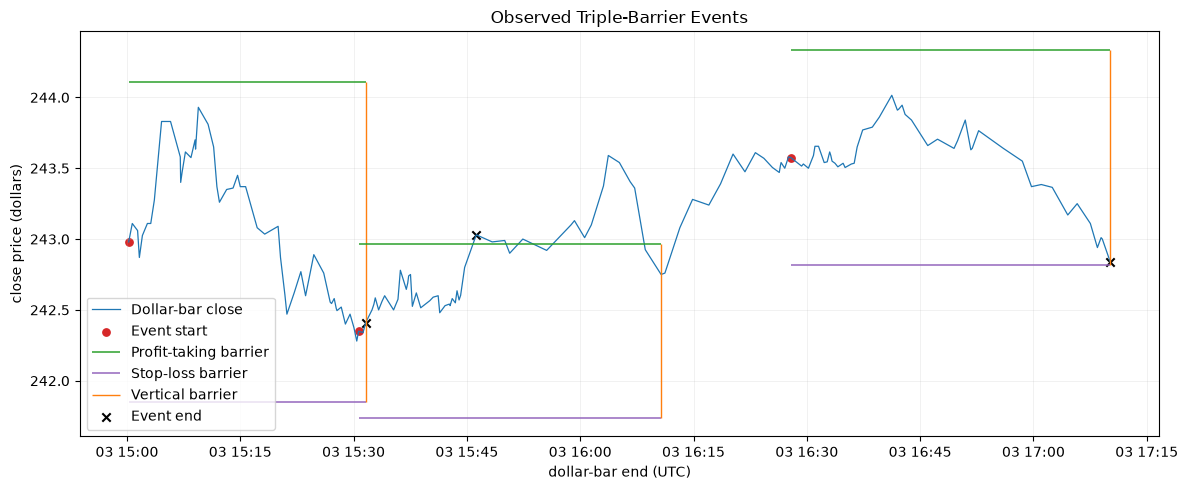

In [6]:
plot_events = primary_model_data.head(3).set_index("event_start")
plot_start = plot_events.index.min()
plot_end = plot_events["vertical_barrier"].max()
plot_close_prices = close_prices.loc[plot_start:plot_end]

figure, axis = plt.subplots(figsize=(12, 5))
axis.plot(
    plot_close_prices.index,
    plot_close_prices,
    color="tab:blue",
    linewidth=0.9,
    label="Dollar-bar close",
)
axis.scatter(
    plot_events.index,
    close_prices.reindex(plot_events.index),
    color="tab:red",
    s=28,
    label="Event start",
)

for event_number, (event_start, event) in enumerate(plot_events.iterrows()):
    event_price = close_prices.loc[event_start]
    upper_barrier = event_price * (1 + event["target_return"])
    lower_barrier = event_price * (1 - event["target_return"])
    axis.hlines(
        upper_barrier,
        event_start,
        event["vertical_barrier"],
        color="tab:green",
        linewidth=1.1,
        label="Profit-taking barrier" if event_number == 0 else None,
    )
    axis.hlines(
        lower_barrier,
        event_start,
        event["vertical_barrier"],
        color="tab:purple",
        linewidth=1.1,
        label="Stop-loss barrier" if event_number == 0 else None,
    )
    axis.vlines(
        event["vertical_barrier"],
        lower_barrier,
        upper_barrier,
        color="tab:orange",
        linewidth=1.0,
        label="Vertical barrier" if event_number == 0 else None,
    )
    axis.scatter(
        event["event_end"],
        close_prices.loc[event["event_end"]],
        color="black",
        marker="x",
        s=36,
        label="Event end" if event_number == 0 else None,
    )

axis.set_xlabel("dollar-bar end (UTC)")
axis.set_ylabel("close price (dollars)")
axis.set_title("Observed Triple-Barrier Events")
axis.grid(alpha=0.25)
axis.legend(loc="best")
figure.tight_layout()
plt.show()


## Direction Label Distribution

This cell visualizes the retained primary-model direction labels.

- The horizontal axis distinguishes negative-return label `-1` from positive-return label `1`.
- The vertical axis reports the number of retained events in each direction class.
- The displayed counts show whether the observed primary target is balanced across the two retained classes.


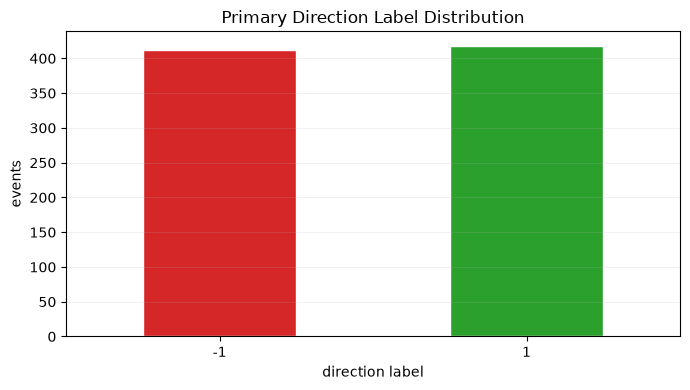

,event_count
direction_label,
-1,412
1,418


In [7]:
direction_counts = primary_model_data["direction_label"].value_counts().sort_index()

distribution_axis = direction_counts.plot.bar(
    figsize=(7, 4),
    color=["tab:red", "tab:green"],
    edgecolor="white",
)
distribution_axis.set_xlabel("direction label")
distribution_axis.set_ylabel("events")
distribution_axis.set_title("Primary Direction Label Distribution")
distribution_axis.grid(axis="y", alpha=0.25)
distribution_axis.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

display(direction_counts.rename("event_count").to_frame())
